In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

def scat(x, y, c,marker):
    return ax.scatter(x, y*100, c=c, ls='-', cmap=cmap, norm=norm, s=30, marker=marker
                     )
import pyccl as ccl
import sys
sys.path.append('../forecasts/')
import fisher_matrix_bao_SuEisenstein
sys.path.append('../survey_design/')
import _tracer_spectroscopic_efficiency
import _survey_design_telescope_metrics
import _surveys
import _survey_design_science_metrics

h=0.677
deltac=1.686
H0=100*h
c_ls=300*10**3
nlim=10000
n_s=0.968

cosmo = ccl.Cosmology(Omega_c=0.27, Omega_b=0.045, h=h, A_s=2.1e-9, n_s=n_s,transfer_function='boltzmann_camb')

In [3]:
import pickle
def save_pickle(dat, filename, **kwargs):
    file = open(filename,'wb')
    pickle.dump(dat, file)
    file.close()
def load(filename, **kwargs):
    with open(filename, 'rb') as fin:
        return pickle.load(fin, **kwargs)

In [4]:
path = '../survey_design/telescope_and_science_metrics/'

In [5]:
survey_design_dark = load(path + 'survey_design_Dark_lbg_only_bao.pkl')
survey_design_dark_qso = load(path + 'survey_design_Dark_qso_only_bao.pkl')
#survey_design_dark_one_tracer = load(path + 'survey_design_Dark_lbg_only_onetracer_approach.pkl')

LBGu = 5180.838323353293
LBGg = 2555.0898203592815
LBGr = 497.0059880239521


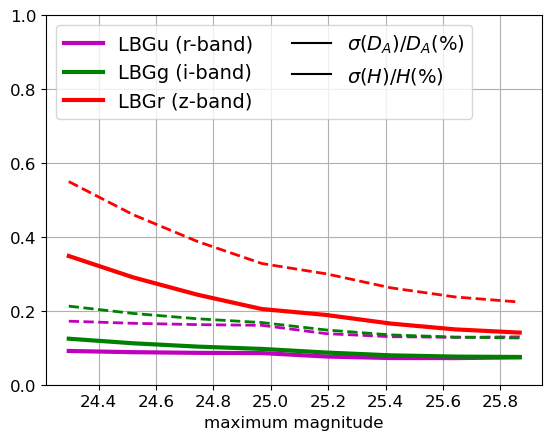

In [13]:
n=0
for k, tracer in enumerate(['LBGu', 'LBGg', 'LBGr']):
    
    survey = survey_design_dark
    i=3
    
    print(tracer, '=', survey['config_survey'][tracer+'_target_density'][i])

    mask_color = np.array(survey['config_survey']['tracers'])==tracer
   
    color = np.array(survey['config_survey']['color'])[mask_color][0]

    


    mask_index_tracer_in_survey = survey["config_survey"]['tracers'] == tracer
    x, y = survey['config_survey'][tracer+'_mag_centers'], 100*np.array(survey['per_tracer_forecasts'][tracer+'_sigma_Da_eff'])
    plt.plot(x, y, '-', label = tracer+ f' ({survey["config_survey"]["limiting_mag_band"][k]}-band)',
                 color = color, lw=3,
                 marker='', )

    x, y = survey['config_survey'][tracer+'_mag_centers'], 100*np.array(survey['per_tracer_forecasts'][tracer+'_sigma_H_eff'])
    plt.plot(x, y, ls='--',
                 color = color, lw=2,
                 )
plt.ylim(0.000, 1)
plt.grid()
#plt.ylim(0.0005, 0.4)
#plt.yscale('log')
#plt.ylabel(r'$\sigma(f_{\rm NL})$', fontsize=15)
plt.xlabel(r'maximum magnitude', fontsize=12)
plt.plot([], [], '-k', label = r'$\sigma(D_A)/D_A (\%)$')
plt.plot([], [], '-k', label = r'$\sigma(H)/H (\%)$')
plt.tick_params(axis='both', labelsize=12)
plt.legend(fontsize=14, ncols=2, loc='upper left')

In [7]:
sigma_omega_m = 1000
h_fid         = 0.677
sigma_H0      = 100.0 * 0.0054

F_prior = np.diag([
    1 / 1e6,                                  # w0  — essentially flat
    1 / 1e6,                                  # wa  — essentially flat
    (h_fid**2 / sigma_omega_m)**2,            # Omega_m, from omega_m prior
    #1 / sigma_H0**2,                          # H0
])
n=0
for k, tracer in enumerate(['LBGu', 'LBGg', 'LBGr']):
    
    survey = survey_design_dark

    x, y = survey['config_survey'][tracer+'_mag_centers'], 100*np.array(survey['per_tracer_forecasts'][tracer+'_sigma_Da_eff'])

    survey['per_tracer_forecasts'][tracer+'_sigma_w0_eff'] = []
    survey['per_tracer_forecasts'][tracer+'_sigma_wa_eff'] = []
    survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'] = []
    err_w0 = []
    err_wa = []
    for i in range(len(survey['per_tracer_forecasts'][tracer+'_zeff_Da'])):
        zeff = survey['per_tracer_forecasts'][tracer+'_zeff_Da'][i]
        sigma_Da_eff = survey['per_tracer_forecasts'][tracer+'_sigma_Da_eff'][i]
        sigma_H_eff = survey['per_tracer_forecasts'][tracer+'_sigma_H_eff'][i]
        
        Fisher_mat_w0wa = fisher_matrix_bao_SuEisenstein.Fisher_mat_BAO_cosmo_params(zeff, sigma_Da_eff, sigma_H_eff, cosmo,  param_names=('w0', 'wa', 'Omega_m'), rel_step=1e-2)
        survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'].append(Fisher_mat_w0wa)
        err_w0.append(np.linalg.inv(Fisher_mat_w0wa + F_prior).diagonal()[0]**.5)
        err_wa.append(np.linalg.inv(Fisher_mat_w0wa + F_prior).diagonal()[1]**.5)
    survey['per_tracer_forecasts'][tracer+'_sigma_w0_eff'] = np.array(err_w0)
    survey['per_tracer_forecasts'][tracer+'_sigma_wa_eff'] = np.array(err_wa)

In [82]:


def plot(lbg_index):# fixed LBGu index
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    # axes: LBGg mag centers (y) vs LBGr mag centers (x)
    x_lbgr = np.array(survey['config_survey']['LBGr_mag_centers'])
    y_lbgg = np.array(survey['config_survey']['LBGg_mag_centers'])
    
    # precompute fixed LBGu Fisher contribution
    Fisher_lbgu = survey['per_tracer_forecasts']['LBGu_Fisher_mat_wOwa_eff'][lbg_index]

    mad_lbgu = np.array(survey['config_survey']['LBGr_mag_centers'][lbg_index])
    
    # build 2D grids
    grid_w0 = np.zeros((len(y_lbgg), len(x_lbgr)))
    grid_wa = np.zeros((len(y_lbgg), len(x_lbgr)))
    
    for j, _ in enumerate(y_lbgg):       # LBGg index  -> y axis
        Fisher_lbgu_g = Fisher_lbgu + survey['per_tracer_forecasts']['LBGg_Fisher_mat_wOwa_eff'][j]
        for i, _ in enumerate(x_lbgr):   # LBGr index  -> x axis
            F_tot = Fisher_lbgu_g \
                  + survey['per_tracer_forecasts']['LBGr_Fisher_mat_wOwa_eff'][i] \
                  + F_prior
            C = np.linalg.inv(F_tot)
            grid_w0[j, i] = np.sqrt(C[0, 0])
            grid_wa[j, i] = np.sqrt(C[1, 1])
    
    # plot
    for ax, grid, label in zip(axs,
                                [grid_w0, grid_wa],
                                [r'$\sigma(w_0)$', r'$\sigma(w_a)$']):
        im = ax.pcolormesh(x_lbgr, y_lbgg, grid, cmap='rainbow', shading='auto')
        fig.colorbar(im, ax=ax)
        ax.set_xlabel(r'LBGr $m < m_{\rm max}$', fontsize=13)
        ax.set_ylabel(r'LBGg $m < m_{\rm max}$', fontsize=13)
        ax.set_title(label + f'  (LBGu r < {mad_lbgu:.1f})', fontsize=13)

    
    plt.tight_layout()
    plt.show()

    

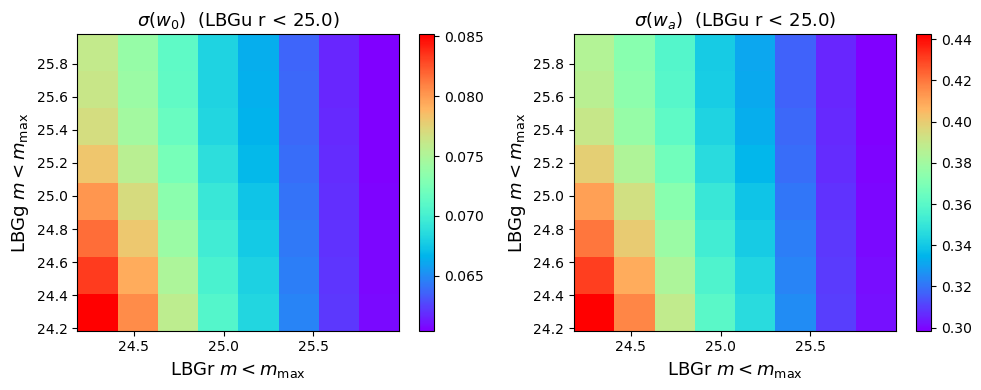

In [83]:
plot(3)

In [14]:

# x = survey_design_dark['config_survey']['LBGu_target_density']

# plt.figure(figsize=(10,4))
# def plot(index, color = None):
#     n=0
#     Fisher_tot = 0
#     for k, tracer in enumerate(['LBGu', 'LBGg']):
        
#             n+=survey['config_survey'][tracer+'_target_density'][index[k]]
#             print(tracer, '=', survey['config_survey'][tracer+'_target_density'][index[k]])
#             Fisher_tot += survey['per_tracer_forecasts'][tracer+'_Fisher_mat_wOwa_eff'][index[k]]

#     x = survey['config_survey']['LBGr_mag_centers']
#     err_w0 = []
#     err_wa = []
#     for i in range(len(x)):
#         Fisher_tot_x = Fisher_tot + survey['per_tracer_forecasts']['LBGr_Fisher_mat_wOwa_eff'][i]
#         err_w0.append(np.linalg.inv(Fisher_tot_x  + F_prior).diagonal()[0]**.5)
#         err_wa.append(np.linalg.inv(Fisher_tot_x + F_prior).diagonal()[1]**.5)
#     plt.subplot(121)
#     plt.plot(x, err_w0, '-', color=color[0],lw=1)
#     plt.subplot(122)
#     plt.plot(x, err_wa, '-', color=color[1], lw=1)

# plot([4,4], color = ['k', 'r'])
# plot([6,6], color = ['k', 'r'])
# plt.subplot(121)
# plt.ylabel(r'$\sigma(w_0)$', fontsize=14)
# plt.xlabel(r'$m < m_{max}$ (MagMax-H or ELG-g)', fontsize=14)
# #plt.ylim(0.8, 1)
# plt.grid(which='both')
# plt.legend(fontsize=11, loc='upper right', ncols=2)
# plt.tick_params(axis='both', labelsize=14)

# plt.subplot(122)
# plt.ylabel(r'$\sigma(w_a)$', fontsize=14)
# plt.xlabel(r'$m < m_{max}$ (MagMax-H of ELG-g)', fontsize=14)
# #plt.ylim(0.8, 1)
# plt.grid(which='both')
# plt.legend(fontsize=11, loc='upper right', ncols=2)
# plt.tick_params(axis='both', labelsize=14)

# plt.subplot(121)
# #plt.ylim(0.06, 0.09)

# plt.subplot(122)
# #plt.ylim(0.45, 0.54)

In [15]:
# def plot_vs_ratio(vary_tracer, denom_tracer, fixed, color=None, density_source=None, lw=1, ls = None, marker = None):
#     """
#     vary_tracer  : tracer whose density array is scanned (e.g. 'LBGg' or 'LBGr')
#     denom_tracer : tracer used as the ratio denominator (e.g. 'LBGu')
#     fixed        : dict {tracer_name: index} for the tracers held fixed
#     color        : [color_w0, color_wa]
#     density_source: dict to pull the varying density array from (defaults to `survey`)
#     """
#     density_source = density_source or survey
#     dens_array = density_source['config_survey'][vary_tracer + '_target_density']

#     Fisher_fixed = 0
#     n_denom = None
#     for tracer, idx in fixed.items():
#         Fisher_fixed += survey['per_tracer_forecasts'][tracer + '_Fisher_mat_wOwa_eff'][idx]
#         n_val = survey['config_survey'][tracer + '_target_density'][idx]
#         if tracer == denom_tracer:
#             n_denom = n_val

#     if n_denom is None:
#         raise ValueError(f"{denom_tracer} must be one of the fixed tracers")

#     ratio, err_w0, err_wa = [], [], []
#     for i in range(len(dens_array)):
#         Fisher_tot = Fisher_fixed + survey['per_tracer_forecasts'][vary_tracer + '_Fisher_mat_wOwa_eff'][i]
#         cov = np.linalg.inv(Fisher_tot  + F_prior)
#         err_w0.append(cov.diagonal()[0]**0.5)
#         err_wa.append(cov.diagonal()[1]**0.5)
#         ratio.append(dens_array[i] / n_denom)

#     plt.plot(ratio, err_w0,  color=color[0], lw=lw, ls=ls[0], marker=marker[0], markersize=3)
#     plt.plot(ratio, err_wa, color=color[1], lw=lw, ls=ls[1], marker=marker[0], markersize=3)
#     plt.xlabel(r'fraction $N_{\rm LBGx}/N_{\rm LBGu}$', fontsize=14)
#     plt.yscale('log')
#     plt.xscale('log')
#     plt.yscale('log')
#     plt.ylim(0.01, 500)
# #plt.xlim(9000, 30000, 5e4)
#     plt.grid(which='both')
#     plt.legend(fontsize=11, loc='upper right', ncols=2)
#     plt.tick_params(axis='both', labelsize=14)
    
#     return ratio, err_w0, err_wa

In [16]:
# import matplotlib.cm as cm
# import matplotlib.colors as mcolors

# n_u = survey['config_survey']['LBGu_target_density']
# N = len(n_u)

# cmap_r = cm.get_cmap('cool')
# cmap_k = cm.get_cmap('cool')  # or use a single-hue cmap, e.g. 'binary'/'bone'
# norm = mcolors.Normalize(vmin=0, vmax=N - 1)

# for i in range(len(survey['config_survey']['LBGu_target_density'])):

#     color_r = cmap_r(norm(i))
#     color_k = cmap_k(norm(i))
#     z=plot_vs_ratio('LBGg', 'LBGu', {'LBGu': i,}, color=[color_r, color_k], density_source=None, lw=1, ls = ['--', '-'], marker = ['o','o'])

# cmap_r = cm.get_cmap('cool')
# cmap_k = cm.get_cmap('cool')  # or use a single-hue cmap, e.g. 'binary'/'bone'
# norm = mcolors.Normalize(vmin=0, vmax=N - 1)
# for i in range(len(survey['config_survey']['LBGu_target_density'])):

#     color_r = cmap_r(norm(i))
#     color_k = cmap_k(norm(i))
#     z=plot_vs_ratio('LBGr', 'LBGu', {'LBGu': i,}, color=[color_r, color_k], density_source=None, lw=1, ls = ['--', '-'], marker = ['',''])

# plt.plot([], [], '-', color='gray', label=r'$\sigma(w_a)$')
# plt.plot([], [], '--',  color='gray', label=r'$\sigma(w_0)$')
# plt.plot([], [], '--w', label = 'dots: vary LBGg')
# plt.plot([], [], '--w', label = 'no dots: vary LBGr')
# plt.grid(which='both')
# plt.legend(fontsize=11, ncols=2, loc='lower left')
# plt.tick_params(axis='both', labelsize=14)

# sm = cm.ScalarMappable(cmap='cool', norm=mcolors.Normalize(vmin=n_u[0], vmax=n_u[-1]))
# sm.set_array([])
# cbar = plt.colorbar(sm, ax=plt.gca())
# cbar.set_label(r'$N_{\rm LBGu}$ [deg$^{-2}$]', fontsize=12)

In [17]:
# n=0
# for k, tracer in enumerate(['LBGu', 'LBGg', 'LBGr']):
    
#     survey = survey_design_dark

#     x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_w0_eff'])
#     mask_color = np.array(survey['config_survey']['tracers'])==tracer
#     color = np.array(survey['config_survey']['color'])[mask_color][0]
#     mask_index_tracer_in_survey = survey["config_survey"]['tracers'] == tracer
#     plt.plot(np.array(x)[y < 1000], np.array(y)[y < 1000],
#                  color = color, 
#                  marker='',label = tracer+ f' ({survey["config_survey"]["limiting_mag_band"][mask_index_tracer_in_survey]}-band)')

#     x, y = survey['config_survey'][tracer+'_mag_centers'], np.array(survey['per_tracer_forecasts'][tracer+'_sigma_wa_eff'])
#     plt.plot(np.array(x)[y < 1000], np.array(y)[y < 1000],
#                  color = color, ls='--',
#                  marker='')

#     #plt.xlim(0, 1.3)
#     plt.ylim(0.01, 500)
# plt.xlabel(r'redshift bin', fontsize=14)
# plt.tick_params(axis='both', labelsize=14)
# plt.yscale('log')
# plt.plot([], [], '-k', label = r'$\sigma(w_0)$')
# plt.plot([], [], '--k', label = r'$\sigma(w_a)$')
# plt.legend(fontsize=11, ncols=2)
# plt.xlabel(r'maximum magnitude', fontsize=14)